In [171]:
import sys
import os

# Добавляем корневую папку проекта в пути поиска Python
sys.path.append(os.path.abspath('..'))

# Команда, чтобы изменения в файлах .py сразу видны были в ноутбуке без перезагрузки ядра (Kernel Restart)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Тестирование - датасет c пингвинами Палмера

## Загрузка и предобработка данных

In [172]:
import pandas as pd

In [173]:
# https://www.kaggle.com/datasets/satyajeetrai/palmer-penguins-dataset-for-eda

In [174]:
s = '../data/penguins.data'

In [175]:
df = pd.read_csv(s)

In [176]:
df = df.dropna()

In [177]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [179]:
import numpy as np

In [180]:
df_binary = df[(df['species'] == 'Adelie') | (df['species'] == 'Chinstrap')]

In [181]:
y = df_binary['species'].values

In [182]:
X = df_binary[['bill_length_mm', 'bill_depth_mm']].values

In [183]:
y = np.where(y == 'Adelie', -1, 1)

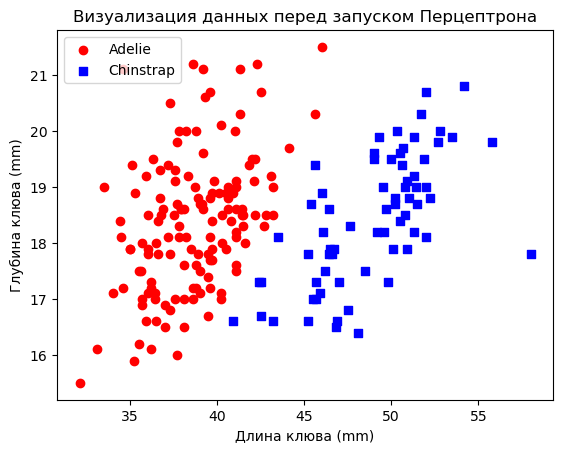

In [184]:
import matplotlib.pyplot as plt

plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', marker='o', label='Adelie')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='s', label='Chinstrap')

plt.xlabel('Длина клюва (mm)')
plt.ylabel('Глубина клюва (mm)')
plt.legend(loc='upper left')
plt.title('Визуализация данных перед запуском Перцептрона')
plt.show()

### Стандартизация данных

In [185]:
X_std = np.copy(X)

In [186]:
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

In [187]:
# Проверка линейной разделимости (примерно)
from sklearn.linear_model import LogisticRegression

# Используем логрегрессию как "эталон"
lr = LogisticRegression(max_iter=1000)
lr.fit(X_std, y)
accuracy = lr.score(X_std, y)

print(f'Точность эталонной модели (LogisticRegression): {accuracy:.2%}')

Точность эталонной модели (LogisticRegression): 97.60%


## Обучение

In [188]:
# Импортируем наш персептрон из src
from src.perceptron import Perceptron

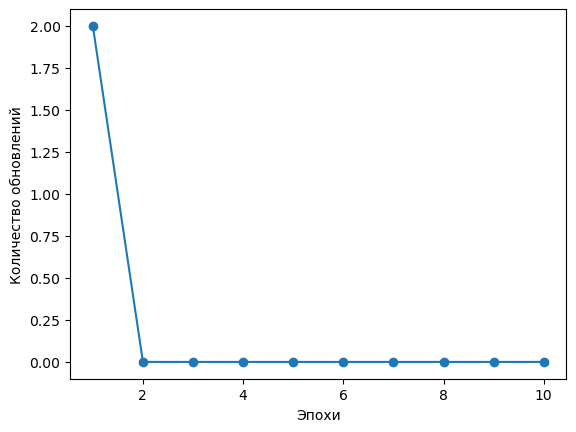

In [189]:
ppn = Perceptron(eta=0.001, n_iter=10)
ppn.fit(X_std, y)
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Количество обновлений')
plt.show()

## Построение границы

In [190]:
# Импортируем метод для рисования границы из src
from src.utils import plot_decision_regions

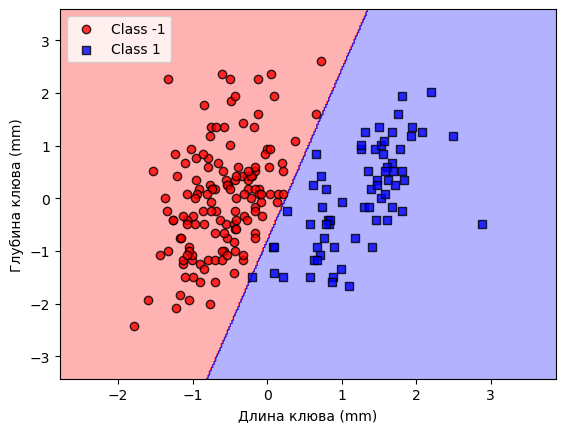

In [191]:
plot_decision_regions(X_std, y, classifier=ppn)
plt.xlabel('Длина клюва (mm)')
plt.ylabel('Глубина клюва (mm)')
plt.legend(loc='upper left')

plt.show()

# Тестирование - датасет ирисов

## Загрузка данных

In [192]:
import pandas as pd

In [193]:
s = '../data/iris.data'

In [194]:
df = pd.read_csv(s, header=None, encoding='utf-8')

In [195]:
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [196]:
import matplotlib.pyplot as plt
import numpy as np

y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)

X = df.iloc[0:100, [0, 2]].values

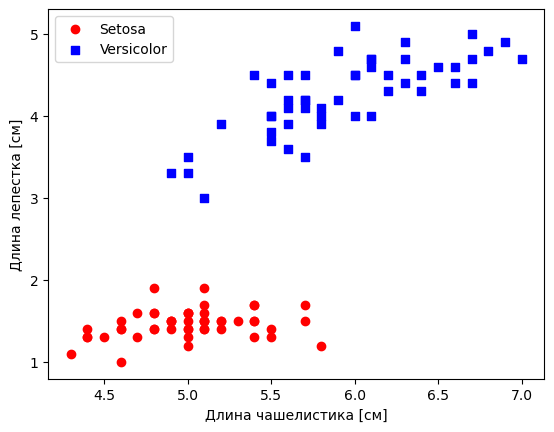

In [197]:
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='s', label='Versicolor')
plt.xlabel('Длина чашелистика [см]')
plt.ylabel('Длина лепестка [см]')
plt.legend(loc='upper left')
plt.show()

## Обучение

In [198]:
# Импортируем наш персептрон из src
from src.perceptron import Perceptron

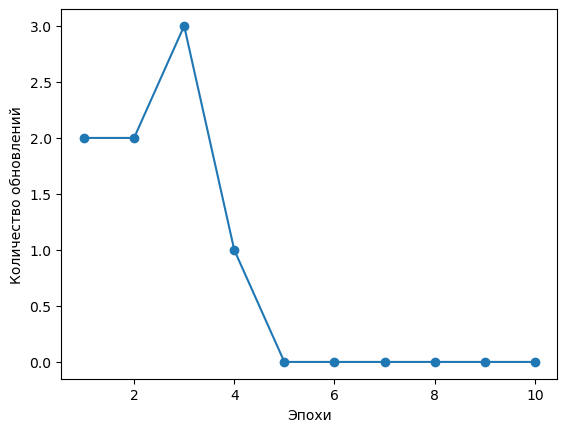

In [199]:
ppn = Perceptron(eta=0.01, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Количество обновлений')
plt.show()

## Построение границы

In [200]:
# Импортируем метод для рисования границы из src
from src.utils import plot_decision_regions

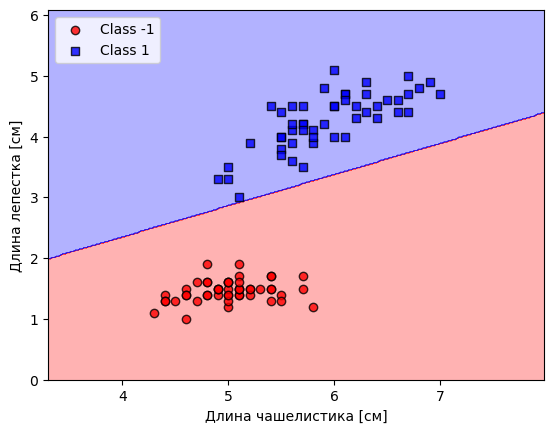

In [201]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('Длина чашелистика [см]')
plt.ylabel('Длина лепестка [см]')
plt.legend(loc='upper left')

plt.show()